# XLand-MiniGrid Data Analysis


In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
from nicewebrl import data_analysis
from flax import serialization
import jax

In [66]:
from nicewebrl.utils import read_all_records

file_path = "/Users/vikramgoddla/nicewebrl_LLM_EnvStage/nicewebrl/examples/xland-LLM-assistant/data/user_data_4094242251.msgpack"
data_dicts = await read_all_records(file_path)

In [67]:
def has_llm_chat(rec: dict) -> bool:
    d = rec.get("data", {})
    return isinstance(d, dict) and "llm_chat_history" in d and bool(d["llm_chat_history"])

sum(1 for r in records if has_llm_chat(r))

0

In [68]:
len(data_dicts)

154

In [63]:
from collections import Counter

# Count field frequencies inside "data"
field_counts = Counter(k for d in data_dicts for k in d.get('data', {}).keys())
print(field_counts.most_common(20))

# Peek at the last few records to see why [-1] didn't have action_taken_time
for d in data_dicts[-5:]:
    print(d.get('type'), list(d.get('data', {}).keys()))

[('image_seen_time', 153), ('action_taken_time', 153), ('computer_interaction', 153), ('action_name', 153), ('action_idx', 153), ('timelimit', 153), ('timestep', 153), ('How helpful was the AI?', 1), ('How human-like was the AI?', 1)]
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']
None ['How helpful was the AI?', 'How human-like was the AI?']


In [43]:
def has_keys(d, *ks):
    return all(k in d.get('data', {}) for k in ks)

action_recs = [d for d in data_dicts
               if has_keys(d, 'image_seen_time', 'action_taken_time')]
print(len(action_recs), "action timesteps")

153 action timesteps


In [44]:
from nicewebrl import time_diff

def has_str(d, key):
    v = d.get('data', {}).get(key)
    return isinstance(v, str) and len(v) > 0

# keep only *valid* action records with both times present as strings
action_recs = [
    d for d in data_dicts
    if has_str(d, 'image_seen_time') and has_str(d, 'action_taken_time')
]

# FIRST valid image_seen_time anywhere in the stream
first_image_ts = next(
    d['data']['image_seen_time'] for d in data_dicts if has_str(d, 'image_seen_time')
)

# LAST valid action_taken_time among action records
last_action_ts = next(
    d['data']['action_taken_time'] for d in reversed(action_recs)
)

start_end_sec = time_diff(first_image_ts, last_action_ts) / 1000
print(f"Total seconds from first timestep to last action: {start_end_sec:.2f}")

pair_ms = [
    time_diff(d['data']['image_seen_time'], d['data']['action_taken_time'])
    for d in action_recs
]
total_timestep_sec = sum(pair_ms) / 1000
print(f"Total seconds across image–action pairs: {total_timestep_sec:.2f}")

Total seconds from first timestep to last action: 43.64
Total seconds across image–action pairs: 57.39


In [45]:
from pprint import pprint

datum = data_dicts[0]
print("-----")
pprint(list(datum.keys()))
print("--- data ---")
pprint(list(datum["data"].keys()))

-----
['stage_idx', 'session_id', 'data', 'user_data', 'metadata', 'name', 'body']
--- data ---
['image_seen_time',
 'action_taken_time',
 'computer_interaction',
 'action_name',
 'action_idx',
 'timelimit',
 'timestep']


In [46]:
print("------")

for key in [
  # "id",  # time-step idx. global
  "session_id",  # browser session id
  "stage_idx",
]:
  print(key, ":", datum[key])

print("--- data ---")
for key in [
  "image_seen_time",
  "action_taken_time",
  "computer_interaction",
  "action_name",
  "action_idx",
]:
  print(key, ":", datum["data"][key])

------
session_id : 630f37f7-578b-4561-a2a7-9f95c3223383
stage_idx : 1
--- data ---
image_seen_time : 2025-08-23T16:05:56.287Z
action_taken_time : 2025-08-23T16:05:57.489Z
computer_interaction : ArrowUp
action_name : Forward
action_idx : 0


In [47]:
datum["metadata"]  # remember, this is for the VERY FIRST timestep of this episode

{'stage_number': 1,
 'type': 'EnvStage',
 'unique_id': 'stage_999e5a7d8ae74f66ab9e182861bc8553',
 'nsteps': 2,
 'nepisodes': 1,
 'nsuccesses': 0}

In [48]:
datum["user_data"]

{'user_id': 3430323227, 'age': 19, 'sex': 'Male'}

In [49]:
def is_str(v): return isinstance(v, str) and len(v) > 0

img_idxs, img_ts = [], []
act_idxs, act_ts = [], []
for i, d in enumerate(data_dicts):
    dd = d.get('data', {})
    if is_str(dd.get('image_seen_time')):
        img_idxs.append(i); img_ts.append(dd['image_seen_time'])
    if is_str(dd.get('action_taken_time')):
        act_idxs.append(i); act_ts.append(dd['action_taken_time'])

print(f"records={len(data_dicts)}  images={len(img_idxs)}  actions={len(act_idxs)}")
print("first image idx:", img_idxs[0] if img_idxs else None, "| ts:", img_ts[0] if img_ts else None)
print("first action idx:", act_idxs[0] if act_idxs else None, "| ts:", act_ts[0] if act_ts else None)
print("image idxs (first 10):", img_idxs[:10])
print("action idxs (first 10):", act_idxs[:10])


records=154  images=153  actions=153
first image idx: 0 | ts: 2025-08-23T16:05:56.287Z
first action idx: 0 | ts: 2025-08-23T16:05:57.489Z
image idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
action idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [50]:
datum = data_dicts[0]["data"]
action_taken: int = datum["action_idx"]
image_seen_time: str = datum["image_seen_time"]
action_taken_time: str = datum["action_taken_time"]
reaction_time: float = data_analysis.compute_reaction_time(datum)

print(f"Reaction time: {reaction_time:.2f} milliseconds")

Reaction time: 1202.00 milliseconds


In [51]:
import jax
from experiment_structure import jax_env, env_params, render_fn

example_timestep = jax_env.reset(key=jax.random.PRNGKey(0), params=env_params)

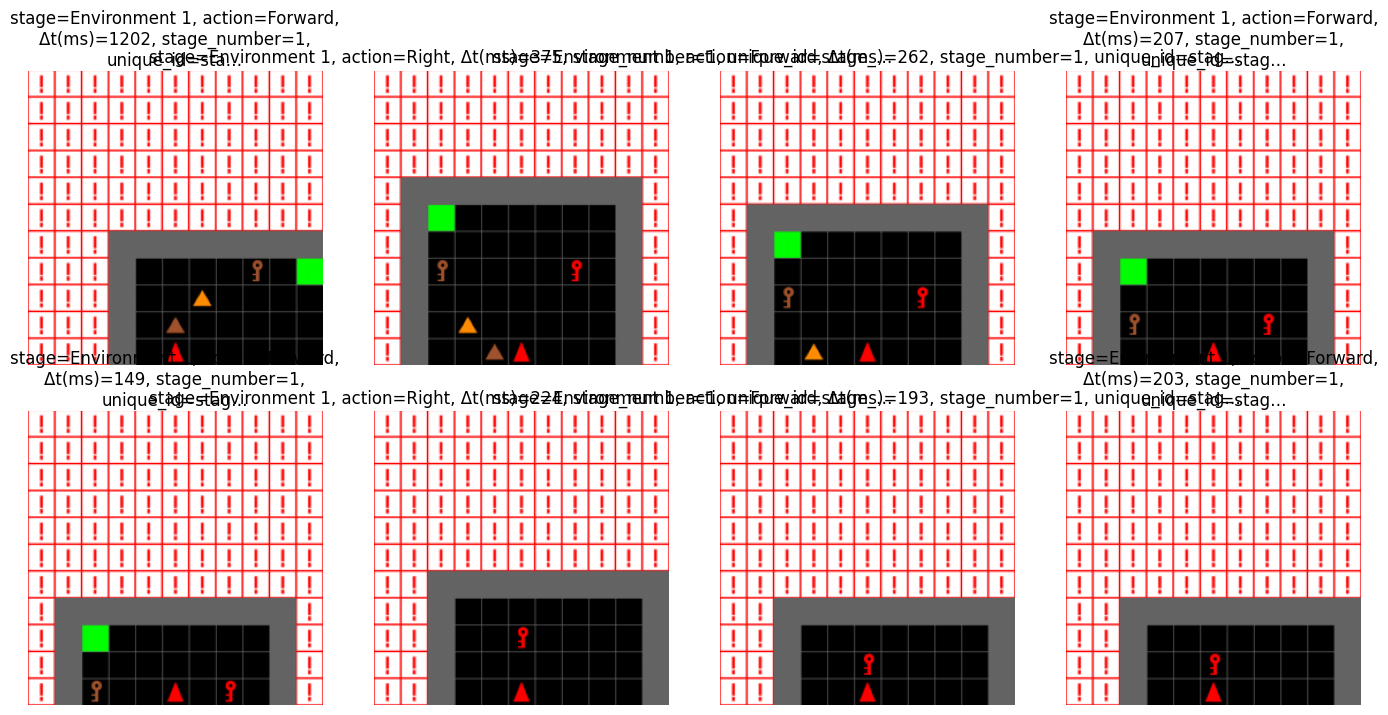

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from flax import serialization

# --- pick a renderer from your codebase ---
try:
    # your project: experiment_structure.py exports render_fn
    from experiment_structure import render_fn as RENDER
except Exception:
    RENDER = None

def dict_to_string(data: dict) -> str:
    return ", ".join(f"{k}={v}" for k, v in data.items())

def shorten(s: str, width: int = 70, placeholder: str = "…") -> str:
    return s if len(s) <= width else s[: max(0, width - len(placeholder))] + placeholder

# Show the first N timesteps as a grid.
# Requires `example_timestep` (a template) and `data_dicts` already loaded.
def show_timesteps(data_dicts, example_timestep, n=6):
    assert RENDER is not None, (
        "Couldn't import a renderer. Make sure experiment_structure.py is on the PYTHONPATH "
        "and exports `render_fn`, or set RENDER to your renderer function."
    )

    # layout
    n = min(n, len(data_dicts))
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.atleast_1d(axes).ravel()

    # optional time delta helper
    try:
        from nicewebrl import time_diff  # returns milliseconds
    except Exception:
        time_diff = None

    for i in range(n):
        datum = data_dicts[i]
        meta = datum.get("metadata", {})
        dd   = datum.get("data", {})

        # reconstruct timestep
        ts_bytes = dd["timestep"]
        timestep = serialization.from_bytes(example_timestep, ts_bytes)

        # render
        img = RENDER(timestep).astype(np.uint8)

        # build a compact title
        act_name = dd.get("action_name")
        key      = dd.get("computer_interaction")
        img_t    = dd.get("image_seen_time")
        act_t    = dd.get("action_taken_time")

        dt_ms = None
        if time_diff and isinstance(img_t, str) and isinstance(act_t, str):
            try:
                dt_ms = round(time_diff(img_t, act_t))
            except Exception:
                dt_ms = None

        title_bits = {
            "stage": datum.get("name"),
            "action": act_name or key,
            "Δt(ms)": dt_ms,
        }
        # include a couple of metadata keys if present
        for k in ("stage_number", "unique_id"):
            if k in meta:
                title_bits[k] = meta[k]

        title = dict_to_string({k: v for k, v in title_bits.items() if v not in (None, "", [])})
        title = shorten(title, 80)

        ax = axes[i]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, wrap=True)

    # hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# --- example usage ---
# show the first 8 timesteps
show_timesteps(data_dicts, example_timestep, n=8)

In [ ]:
# --- LLM chat history: table + threaded view (1 row per record) ---

import pandas as pd
from textwrap import fill

def extract_llm_history(data_dicts, mode="last_per_record"):
    """
    mode:
      - 'all'              : every turn from every record (original behavior)
      - 'last_per_record'  : only the last turn from each record (what you want)
      - 'first_per_record' : only the first turn from each record
    """
    rows = []
    for rec_idx, rec in enumerate(data_dicts):
        data = rec.get("data", {}) or {}
        meta = rec.get("metadata", {}) or {}
        hist = data.get("llm_chat_history")
        if not hist:
            continue

        # normalize
        if isinstance(hist, dict):
            hist = [hist]
        if not isinstance(hist, list):
            continue

        # choose which turns to keep
        if mode == "last_per_record":
            turns = [hist[-1]]
            base_turn_idx = len(hist)  # for reference if you want to keep the index
        elif mode == "first_per_record":
            turns = [hist[0]]
            base_turn_idx = 1
        else:  # 'all'
            turns = hist
            base_turn_idx = None

        for i, turn in enumerate(turns, start=1):
            prompt   = turn.get("prompt")   or turn.get("user")      or turn.get("question") or ""
            response = turn.get("response") or turn.get("assistant") or turn.get("answer")   or ""
            ts       = turn.get("timestamp") or data.get("action_taken_time") or data.get("image_seen_time")

            rows.append({
                "rec_idx": rec_idx,
                "stage": rec.get("name"),
                "stage_number": meta.get("stage_number"),
                "turn": (base_turn_idx if base_turn_idx is not None else i),
                "timestamp": ts,
                "prompt": prompt,
                "response": response,
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df = df.sort_values(["rec_idx"], kind="stable").reset_index(drop=True)
    return df

# Use the 'last_per_record' mode to get exactly 1 row per record
df_llm = extract_llm_history(data_dicts, mode="last_per_record")

# ---- Summary ----
if df_llm.empty:
    print("No llm_chat_history found in the loaded records.")
else:
    print(f"Records with llm_chat_history: {df_llm['rec_idx'].nunique()}")
    print(f"Total rows shown (one per record): {len(df_llm)}")
    with pd.option_context("display.max_colwidth", 120):
        display(df_llm[["timestamp", "stage", "turn", "prompt", "response"]])


Records with llm_chat_history: 86
Total rows shown (one per record): 86


,timestamp,stage,turn,prompt,response
0,2025-08-23 16:24:29.935596+00:00,Environment 1,1,what am i supposed to do?,"To achieve your goal of holding the purple hexagon, follow these steps:\n\n1. **Identify Nearby Objects**: Check you..."
1,2025-08-23 16:24:29.935596+00:00,Environment 1,1,what am i supposed to do?,"To achieve your goal of holding the purple hexagon, follow these steps:\n\n1. **Identify Nearby Objects**: Check you..."
2,2025-08-23 16:24:29.935596+00:00,Environment 1,1,what am i supposed to do?,"To achieve your goal of holding the purple hexagon, follow these steps:\n\n1. **Identify Nearby Objects**: Check you..."
3,2025-08-23 16:24:29.935596+00:00,Environment 1,1,what am i supposed to do?,"To achieve your goal of holding the purple hexagon, follow these steps:\n\n1. **Identify Nearby Objects**: Check you..."
4,2025-08-23 16:24:29.935596+00:00,Environment 1,1,what am i supposed to do?,"To achieve your goal of holding the purple hexagon, follow these steps:\n\n1. **Identify Nearby Objects**: Check you..."
...,...,...,...,...,...
81,2025-08-23 16:24:56.369666+00:00,Environment 3,1,what color key do i need?,You need a **brown key** to access the green goal (down goal).
82,2025-08-23 16:24:56.369666+00:00,Environment 3,1,what color key do i need?,You need a **brown key** to access the green goal (down goal).
83,2025-08-23 16:24:56.369666+00:00,Environment 3,1,what color key do i need?,You need a **brown key** to access the green goal (down goal).
84,2025-08-23 16:24:56.369666+00:00,Environment 3,1,what color key do i need?,You need a **brown key** to access the green goal (down goal).


In [36]:
import json
from itertools import islice

path = "/Users/vikramgoddla/nicewebrl_LLM_EnvStage/nicewebrl/examples/xland-LLM-assistant/data/user_data_649028474.json"  # <-- replace with the actual path to your saved JSON

# Load just the first 5 records
with open(path, "r") as f:
    first_records = list(islice((json.loads(line) for line in f), 5))

print("First 5 records:")
for i, rec in enumerate(first_records, 1):
    print(f"\nRecord {i}:")
    print(json.dumps(rec, indent=2)[:1000])  # truncate for readability

# Also peek at the last few records
with open(path, "r") as f:
    last_records = list(islice((json.loads(line) for line in f), 10000))[-5:]
print("\nLast 5 records:")
for i, rec in enumerate(last_records, 1):
    print(f"\nRecord -{5-i}:")
    print(json.dumps(rec, indent=2)[:1000])


First 5 records:

Record 1:
{
  "finished": true,
  "feedback": "AI was helpful for understanding the task",
  "user_storage": {
    "seed": 649028474,
    "rng_splits": 160,
    "rng_key": [
      2140441423,
      2659488343
    ],
    "init_rng_key": [
      0,
      649028474
    ],
    "session_start": "2025-08-23T11:45:42.371718",
    "session_duration": 0,
    "worker_id": null,
    "hit_id": null,
    "assignment_id": null,
    "user_id": 649028474,
    "stage_idx": 5,
    "stage_name": "Feedback",
    "num_stages": 5,
    "container_ce8b0fe21cb44d9da68d5e40403e7020_data": {
      "stage_order": [
        0,
        1,
        3,
        2,
        4
      ]
    },
    "stage_progress": 1.2,
    "age": 19,
    "sex": "Male",
    "experiment_started": true,
    "data_saved": false,
    "experiment_finished": true
  }
}

Last 5 records:

Record -4:
{
  "finished": true,
  "feedback": "AI was helpful for understanding the task",
  "user_storage": {
    "seed": 649028474,
    "rng_

In [56]:
import json, msgpack, io, pprint, itertools

# --- Load your saved data file (JSON or msgpack) ---
path = "/Users/vikramgoddla/nicewebrl_LLM_EnvStage/nicewebrl/examples/xland-LLM-assistant/data/user_data_3350787000.msgpack"   # <-- replace with your actual file name

def load_records(path):
    with open(path, "rb") as bf:
        head = bf.read(4)
        bf.seek(0)
        if path.endswith(".msgpack") or head[:1] not in (b"{", b"["):
            unpacker = msgpack.Unpacker(bf, raw=False, strict_map_key=False)
            return [obj for obj in unpacker if isinstance(obj, dict)]
        else:
            recs = []
            for line in bf:
                line = line.strip()
                if not line:
                    continue
                try:
                    recs.append(json.loads(line.decode("utf-8")))
                except Exception:
                    pass
            return recs

records = load_records(path)
print("Loaded", len(records), "records")

# --- Walk function to search for llm fields ---
def walk(obj, path=""):
    if isinstance(obj, dict):
        for k,v in obj.items():
            newp = f"{path}.{k}" if path else k
            if "llm" in k.lower():
                print("FOUND:", newp, "->", type(v).__name__)
            walk(v, newp)
    elif isinstance(obj, list):
        for i,v in enumerate(obj):
            walk(v, f"{path}[{i}]")

# --- Inspect first few records ---
for i, rec in enumerate(records[:3], 1):
    print(f"\n=== Record {i} top-level keys ===")
    pprint.pprint(list(rec.keys()))
    walk(rec)


FormatError: 

In [58]:
def find_llm_chat(records):
    found = []
    for i, rec in enumerate(records):
        # Look at all dicts: top level and 'data'
        if "llm_chat_history" in rec:
            found.append((i, "root", rec["llm_chat_history"]))
        data = rec.get("data", {})
        if "llm_chat_history" in data:
            found.append((i, "data", data["llm_chat_history"]))
    return found

hits = find_llm_chat(records)
print(f"Found {len(hits)} records with llm_chat_history")
for rec_idx, where, val in hits[:3]:
    print(f"\nRecord {rec_idx} ({where}):")
    print(val)

Found 0 records with llm_chat_history


In [ ]:
# --- exports ---
OUT_DIR = DATA_DIR / 'analysis_exports'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not df.empty:
    df.to_csv(OUT_DIR / 'raw_records_flat.csv', index=False)
if 'step_df' in locals() and not step_df.empty:
    step_df.to_csv(OUT_DIR / 'steps.csv', index=False)
if 'chat_df' in locals() and not chat_df.empty:
    chat_df.to_csv(OUT_DIR / 'llm_chat.csv', index=False)

print('Exports written to:', OUT_DIR.resolve())
